# **TP1 - Sistemas de Inteligencia Artificial**
## Regresión con Modelos Lineales
#### Dataset: Properati Bs. As. 2020 ([Kaggle](https://www.kaggle.com/datasets/alejandromendivil/bsas-realstate-on-sale/))

 **Introducción teórica**

**Modelos Lineales:**

Son aquellos que tienen la forma:

$\hat{y} =\beta_0 +\beta_1 x_1 + \beta_2 x_2 + .. +\beta_n x_n$

o, vectorialmente

$\hat{y} = \vec{\beta} \cdot \vec{x}$

donde $\hat{y}$ es la predicción,
$n$ es el número de _features_ o variables predictoras, $x_i$ es el i-ésimo feature y $\vec{\beta}$ es el vector de parámetros o _pesos_ del modelo (lo que entrenamos).

**Modelos lineales regularizados:**

En los modelos lineales simples, los parámetros $\beta_i$ se ajustan minimizando el error cuadrático medio entre las predicciones y los valores reales. Sin embargo, cuando hay **muchas variables**, correlaciones fuertes entre ellas o riesgo de *overfitting*, se utilizan **términos de regularización** que penalizan la magnitud de los coeficientes, mejorando así la capacidad de generalización del modelo.

Algunos ejemplos:

- **Ridge Regression** (*L2 regularization*):  

  $\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^n \beta_i^2$

  Tiende a mantener todos los coeficientes pequeños pero distintos de cero.

- **Lasso Regression** (*L1 regularization*):  

  $\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^n |\beta_i|$

  Puede forzar coeficientes exactamente a cero, funcionando también como método de selección de variables.

- **Elastic Net**: combina L1 y L2, balanceando sus ventajas.



**Modelos lineales con *features* polinomiales:**

Los modelos lineales pueden extenderse para capturar relaciones **no lineales** entre las variables de entrada y la variable objetivo mediante la creación de nuevas variables que son **combinaciones polinomiales** de las originales.

Por ejemplo, con dos variables $x_1$ y $x_2$ y un polinomio de grado 2, el modelo considera:  
$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1^2 + \beta_4 x_2^2 + \beta_5 x_1 x_2
$  

Aunque la relación entre las *features* y $\hat{y}$ puede ser no lineal, el modelo sigue siendo **lineal en los parámetros** $\beta_i$, por lo que conserva las propiedades y métodos de ajuste de los modelos lineales clásicos.

Este enfoque, **combinado con regularización**, permite capturar patrones complejos sin perder el control sobre el sobreajuste.


------------------------
------------------------
**Instrucciones:**

- **No** modificar las celdas de texto.

- Resolver cada consigna en su sección correspondiente. Recuerden que lo más importante es el razonamiento y justificación de los pasos para demostrar comprensión del problema a resolver, por lo tanto **deben ir COMENTANDO en la notebook las decisiones que van tomando y las interpretaciones que hagan de los resultados**. Pueden usar las funciones que definimos en las clases.

- **ENTREGA:** Ir a Archivo > Descargar .ipynb. Este archivo .ipynb deberán subirlo al campus junto con las diapositivas en formato PDF (archivo no editable) hasta las 23:59hs del día anterior a la presentación. La presentación oral de este último documento será de manera grupal en hasta 5 minutos el día asignado durante el horario de clase (se sorteará el orden de los grupos al azar). Dado el tiempo de exposición, recomendamos un máximo de 4 diapositivas.

- **Consignas presentacion:** La presentación debe tener un máximo de 4 diapositivas y una duración aproximada de **5 minutos**. La estructura de las diapositivas debe ser la siguiente:
  1. Presentación del grupo y del problema a resolver.
  2. Datos y pre-procesamiento.
  3. Modelado.
  4. Resultados/Conclusiones.

Durante la presentación deberán explicar claramente las siguientes etapas del trabajo:
- Análisis exploratorio de datos (EDA):
Qué observaron en los datos: estructura del dataset, variables importantes, valores faltantes, distribuciones, posibles outliers y relaciones entre variables.

- Modelos y ajuste fino (tuning):
Qué modelos probaron, por qué los eligieron y cómo ajustaron sus parámetros o configuraciones para mejorar el rendimiento.

- Evaluación y testeo del modelo:
Cómo evaluaron el modelo, qué métricas utilizaron y qué resultados obtuvieron en el conjunto de test.

El objetivo de esta presentación es mostrar que realmente comprendieron el proceso que realizaron y que pueden explicarlo de manera clara.

------------------------
------------------------

# 1. Importar librerías

In [9]:
# las librerías escenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Libreria para la parte regresion
#Go permite crear graficos interactivos
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# 2. Definición del problema

- **¿Cuál es la tarea que queremos hacer con aprendizaje automático?**
  - Predecir el precio de las propiedades.
- **¿Qué métrica de evaluación vamos a usar?**
  - Utilizaremos el RMSE (_root mean squared error_).


# 3. Cargar los datos

In [10]:
# Cargamos el dataset de Kaggle
import kagglehub
import os

path = kagglehub.dataset_download("alejandromendivil/bsas-realstate-on-sale")
csv_file_path = os.path.join(path, 'bsas_realstate_on_sale_properati_dataset_2020.csv')

df = pd.read_csv(csv_file_path) # lo guardamos en un DataFrame de pandas

# El dataset teniendo muchas filas, decidimos interesarnos unicamente a los departamentos de Capital Federal
df = df[df['l2'] == "Capital Federal"]  # Importante correr esta línea!

# 4.  Crear conjunto de test

---
Primero se realiza una separación del dataset en conjuntos de entrenamiento y testeo utilizando, por ejemplo, ```train_test_split```. El conjunto de entrenamiento se utiliza para ajustar el modelo, mientras que el conjunto de prueba permite evaluar su rendimiento sobre datos que el modelo no ha visto durante el entrenamiento.

**Separación de datos**
  - Crear los conjuntos de entrenamiento y testeo `X_train`, `X_test`, `y_train`, `y_test` (sug: `train_test_split`).

In [ ]:
# importamos la función train_test_split para poder utilizarla para dividir
from sklearn.model_selection import train_test_split 

#Separamos las variables que usamos como datos de entrada (X) de la variable objetivo que queremos predecir (y)
X = df.drop(columns=['price']) 
Y = df['price']

# Spliteamos con ayuda de la función train_test_split, el 20% de los datos para prueba y el 80% para entrenamiento (es lo estándar)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(74031, 18) (18508, 18) (74031,) (18508,)


# 5.  Análisis exploratorio de datos

---


*Antes de entrenar un modelo de aprendizaje automático, es fundamental explorar y comprender el conjunto de datos. El análisis exploratorio de datos (EDA) permite examinar la estructura del dataset, identificar los tipos de variables, detectar valores faltantes y observar la distribución de los datos. Además, ayuda a encontrar posibles valores atípicos (outliers) y a entender cómo están organizadas las diferentes variables.
En esta sección analizaremos la estructura del dataset, verificaremos la presencia de valores nulos y exploraremos las distribuciones y relaciones entre variables para asegurarnos de que los datos están listos para las etapas posteriores de modelado.*

---



Acá comienzan ustedes..
- 5.1) **Conocer los datos**
  - Explorar la estructura del dataset: cantidad de columnas y filas, tipos de datos, entender qué significa cada variable (métodos relevantes: `head()`, `info()`, `describe()`).
  - Identificar variables numéricas y categóricas.
  - Identificar si hay variables irrelevantes o redundantes.


In [12]:
X_train.head(5)

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,currency,title,description,property_type,operation_type
52709,2019-07-29,2019-08-17,2019-07-29,-34.625519,-58.415173,Argentina,Capital Federal,Boedo,3.0,2.0,1.0,55.0,55.0,USD,3 Amb. Muy Amplios Bajas Expensas Excelente Es...,Corredor Responsable: Veronica Grela Reina - C...,Departamento,Venta
114700,2019-10-12,2019-10-22,2019-10-12,-34.562241,-58.442706,Argentina,Capital Federal,Belgrano,4.0,3.0,4.0,172.0,156.0,USD,Departamento de 4 ambientes con cochera en ven...,Con una excelente ubicación en el barrio de Be...,Departamento,Venta
83370,2020-01-25,2020-02-11,2020-01-25,-34.597355,-58.447126,Argentina,Capital Federal,Villa Crespo,2.0,1.0,1.0,37.0,37.0,USD,Departamento de 2 ambientes en Venta en Villa ...,DEPARTAMENTO 2 AMBIENTES - 2do. PISO POR ESCAL...,Departamento,Venta
53474,2019-05-03,2019-06-23,2019-05-03,-34.595118,-58.509362,Argentina,Capital Federal,Villa Devoto,3.0,2.0,1.0,57.0,54.0,USD,Venta departamento,"Impecable 3 ambientes con balcon, contrafrente...",Departamento,Venta
40310,2019-12-19,9999-12-31,2019-12-19,-34.568029,-58.451498,Argentina,Capital Federal,Belgrano,4.0,3.0,3.0,145.0,133.0,USD,Departamento en Venta en Belgrano 4 Amb + Dep ...,Excelente departamento en Belgrano a metros de...,Departamento,Venta


In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74031 entries, 52709 to 24555
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   start_date       74031 non-null  object 
 1   end_date         74031 non-null  object 
 2   created_on       74031 non-null  object 
 3   lat              70367 non-null  float64
 4   lon              70355 non-null  float64
 5   l1               74031 non-null  object 
 6   l2               74031 non-null  object 
 7   l3               74031 non-null  object 
 8   rooms            74031 non-null  float64
 9   bedrooms         74031 non-null  float64
 10  bathrooms        72009 non-null  float64
 11  surface_total    66562 non-null  float64
 12  surface_covered  66155 non-null  float64
 13  currency         74031 non-null  object 
 14  title            74031 non-null  object 
 15  description      74031 non-null  object 
 16  property_type    74031 non-null  object 
 17  operation_typ

Variables categóricas: l1, l2, l3, currency, property_type, operation_type, title y description
* l1, l2, currency y operation_type poseen una única categoría por lo que decidimos dropearlas

Variables numéricas: rooms, bedrooms, bathrooms, surface_total, surface_covered

Variables temporales:start_date, end_date y created_on

In [14]:
X_train["start_date"] = pd.to_datetime(X_train["start_date"])
X_train["end_date"] = pd.to_datetime(X_train["end_date"], "coerce")
X_train["created_on"] = pd.to_datetime(X_train["created_on"])

X_test["start_date"] = pd.to_datetime(X_test["start_date"])
X_test["end_date"] = pd.to_datetime(X_test["end_date"], "coerce")
X_test["created_on"] = pd.to_datetime(X_test["created_on"])

C:\Users\matut\AppData\Local\Temp\ipykernel_12816\3682753237.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_test["end_date"] = pd.to_datetime(X_test["end_date"], "coerce")


In [15]:
X_train["operation_type"].value_counts()

operation_type
Venta    74031
Name: count, dtype: int64

In [16]:
X_train["property_type"].value_counts()

property_type
Departamento       63230
PH                  7774
Casa                2177
Oficina              366
Lote                 192
Otro                  98
Cochera               87
Local comercial       83
Depósito              23
Casa de campo          1
Name: count, dtype: int64

In [17]:
X_train["currency"].value_counts()

currency
USD    74031
Name: count, dtype: int64

In [18]:
X_train = X_train.drop(columns=["l1","l2","operation_type","currency"])
X_train["barrio"] = X_train["l3"].str.lower()
X_train = X_train.drop(columns=["l3"])
X_train.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'rooms',
       'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'barrio'],
      dtype='object')

In [19]:
X_train.describe().T

,count,mean,min,25%,50%,75%,max,std
start_date,74031,2019-07-31 12:22:14.554443264,2019-01-01 00:00:00,2019-04-29 00:00:00,2019-07-31 00:00:00,2019-11-12 00:00:00,2020-01-25 00:00:00,NaN
end_date,64960,2019-08-31 21:34:10.935960576,2019-01-04 00:00:00,2019-06-23 00:00:00,2019-08-17 00:00:00,2019-12-07 00:00:00,2020-03-25 00:00:00,NaN
created_on,74031,2019-07-31 12:22:14.554443264,2019-01-01 00:00:00,2019-04-29 00:00:00,2019-07-31 00:00:00,2019-11-12 00:00:00,2020-01-25 00:00:00,NaN
lat,70367.0,-34.599162,-34.696419,-34.613858,-34.599477,-34.584205,-34.535818,0.024018
lon,70355.0,-58.435843,-58.530468,-58.459418,-58.4337,-58.40962,-58.354919,0.036341
rooms,74031.0,2.965001,1.0,2.0,3.0,4.0,26.0,1.328184
bedrooms,74031.0,1.960017,0.0,1.0,2.0,3.0,15.0,1.085919
bathrooms,72009.0,1.562874,1.0,1.0,1.0,2.0,14.0,0.863227
surface_total,66562.0,113.797858,10.0,49.0,71.0,112.0,126062.0,970.304998
surface_covered,66155.0,94.663684,1.0,44.0,63.0,96.0,126062.0,708.637561


- 5.2) **Valores faltantes**
  - Calcular el porcentaje de valores nulos por columna.
  - Imputar valores faltantes si hay. Decidir qué estrategia de imputación usar para variables numéricas y para categóricas (sug: `SimpleImputer`).

Vemos el porcentaje de valores faltantes para cada columna

In [20]:
X_train.isnull().mean().sort_values(ascending=False).round(3)

end_date           0.123
surface_covered    0.106
surface_total      0.101
lon                0.050
lat                0.049
bathrooms          0.027
rooms              0.000
created_on         0.000
start_date         0.000
bedrooms           0.000
title              0.000
description        0.000
property_type      0.000
barrio             0.000
dtype: float64

Para las columnas numéricas con valores faltantes que no son geográficas decidimos utilizar el SimpleImputer por la mediana para evitar posibles movimientos por outliers

In [21]:
X_train.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'rooms',
       'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'barrio'],
      dtype='object')

In [22]:
from sklearn.impute import KNNImputer

cols_referencia = ["rooms", "bedrooms"]

for col in ["bathrooms", "surface_total", "surface_covered"]:

    cols_knn = cols_referencia + [col]

    imputer = KNNImputer(n_neighbors=5)

    X_train[col] = imputer.fit_transform(X_train[cols_knn])[:, -1]
    X_test[col] = imputer.transform(X_test[cols_knn])[:, -1]

Para latitud y longitud utilizamos la mediana según l3 que es el barrio para que tenga un sentido más lógico de imputación que la mediana general de capital federal

In [23]:
X_train["lat"] = X_train.groupby("barrio")["lat"].transform(lambda x: x.fillna(x.median()))
X_train["lon"] = X_train.groupby("barrio")["lon"].transform(lambda x: x.fillna(x.median()))

X_train[["lat", "lon"]].isnull().mean()

lat    0.0
lon    0.0
dtype: float64

In [24]:
X_train["rooms"] = X_train["rooms"].astype(int)
X_test["rooms"] = X_test["rooms"].astype(int)

X_train["bedrooms"] = X_train["bedrooms"].astype(int)
X_test["bedrooms"] = X_test["bedrooms"].astype(int)

X_train["bathrooms"] = X_train["bathrooms"].astype(int)
X_test["bathrooms"] = X_test["bathrooms"].astype(int)

Se convierten ahora porque bathrooms tenía nulos y de otra forma no podía hacerse

- 5.3) **Distribuciones de variables y valores atípicos**
  - Graficar histogramas, boxplots o violinplots para variables numéricas.
  - Identificar valores atípicos y limpiarlos de ser necesario.
  - Graficar conteos para variables categóricas (sug: `value_counts()` o `sns.countplot()`).

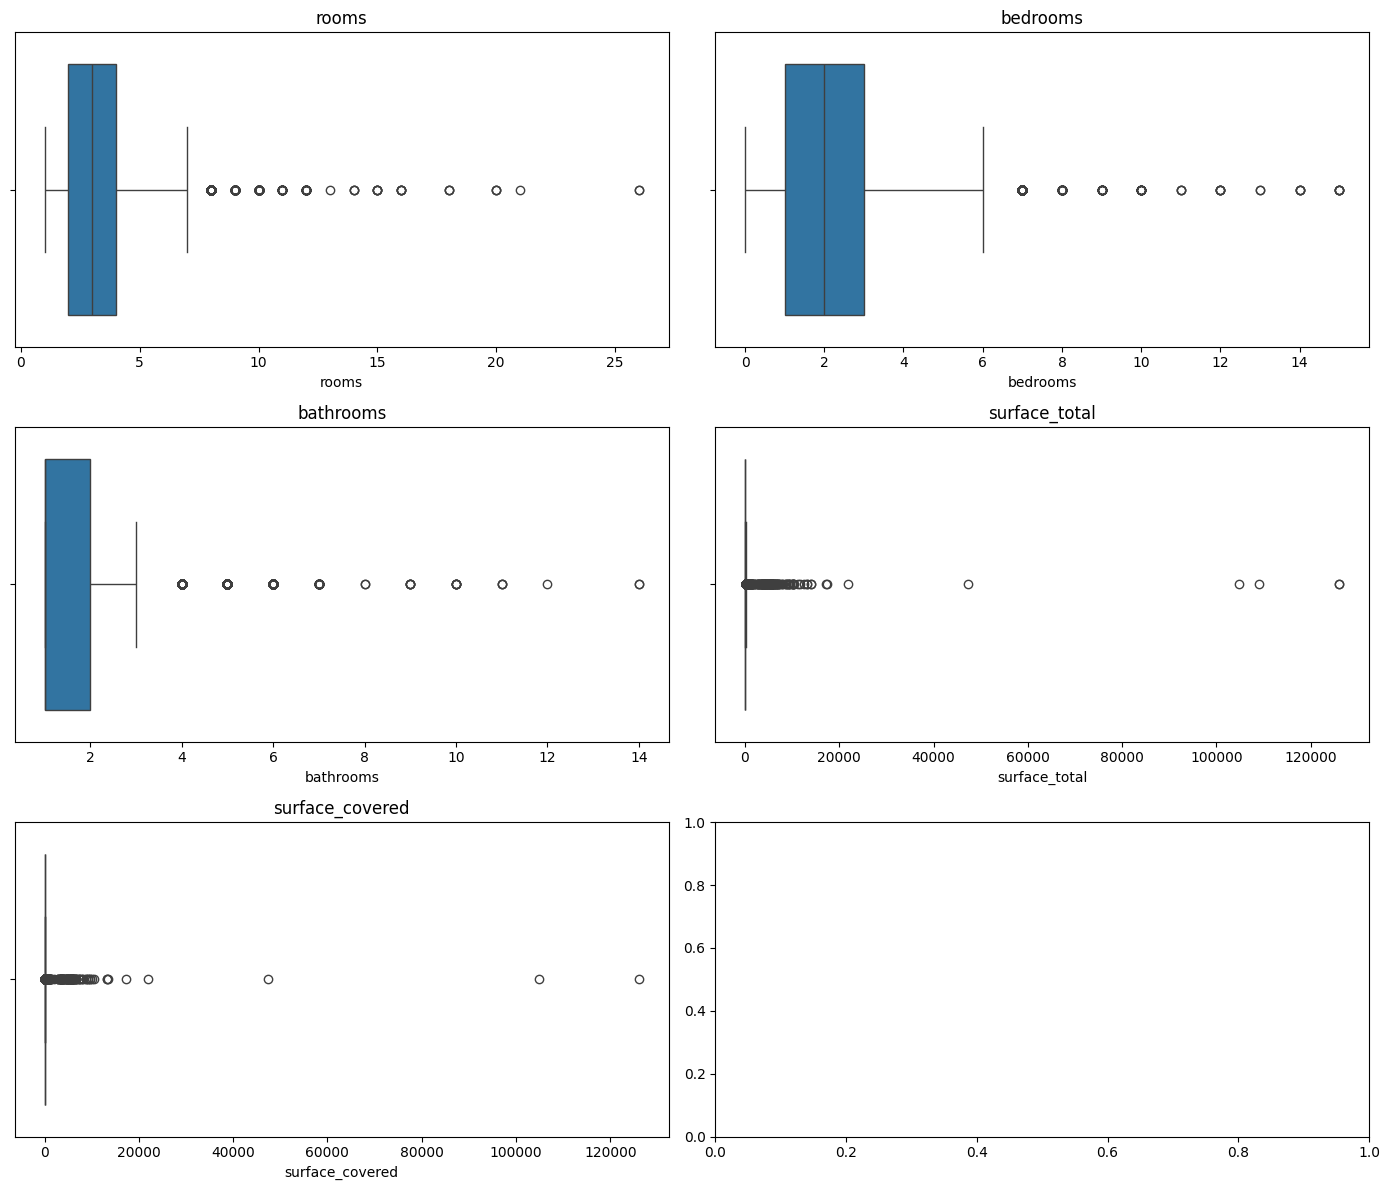

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

cols_boxplot = ["rooms", "bedrooms", "bathrooms", "surface_total", "surface_covered"]

for ax, col in zip(axes.flatten(), cols_boxplot):
    sns.boxplot(x=X_train[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Observando los boxplots se puede ver que hay una gran cantidad de outliers en la mayoría de las variables, en específico para valores altos. Por ejemplo, en surface_covered o surface_total se puede ver claramente que son 2 o 3 valores los que distorsionan por completo el gráfico al comprimir la caja a una línea. Debido a esto, decidimos que nuestro próximo paso fuera eliminar esos outliers.

In [26]:
cols_outliers = [
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered"]

def eliminar_outliers_iqr(X, y=None, cols=None, X_referencia=None):
    if X_referencia is None:
        X_referencia = X

    Q1 = X_referencia[cols].quantile(0.25)
    Q3 = X_referencia[cols].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    mask = (X[cols] < limite_inf) | (X[cols] > limite_sup)

    print("Número de outliers por variable:")
    print(mask.sum())

    indices_outliers = X[mask.any(axis=1)].index
    X_limpio = X.drop(indices_outliers)

    if y is not None:
        y_limpio = y.drop(indices_outliers)
        return X_limpio, y_limpio

    return X_limpio

X_train, y_train = eliminar_outliers_iqr(X_train, y_train, cols_outliers, X_referencia=X_train)

Número de outliers por variable:
rooms               537
bedrooms            226
bathrooms          2679
surface_total      5153
surface_covered    5053
dtype: int64


In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66840 entries, 52709 to 24555
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   start_date       66840 non-null  datetime64[ns]
 1   end_date         58423 non-null  datetime64[ns]
 2   created_on       66840 non-null  datetime64[ns]
 3   lat              66840 non-null  float64       
 4   lon              66840 non-null  float64       
 5   rooms            66840 non-null  int64         
 6   bedrooms         66840 non-null  int64         
 7   bathrooms        66840 non-null  int64         
 8   surface_total    66840 non-null  float64       
 9   surface_covered  66840 non-null  float64       
 10  title            66840 non-null  object        
 11  description      66840 non-null  object        
 12  property_type    66840 non-null  object        
 13  barrio           66840 non-null  object        
dtypes: datetime64[ns](3), float64(4), int64

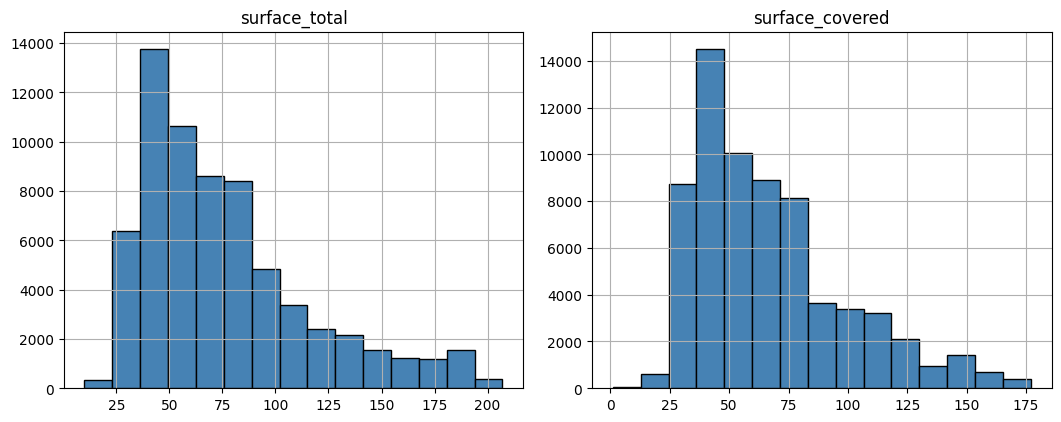

In [28]:
num_cols = ["surface_total", "surface_covered"]

X_train[num_cols].hist(figsize=(16, 12), bins=15, color="steelblue", edgecolor="black", layout=(3, 3))
plt.tight_layout()
plt.show()

Ambas variables presentan una distribución asimétrica hacia la derecha, con mayor concentración de propiedades en superficies medias y una menor cantidad de observaciones a medida que aumenta la superficie.

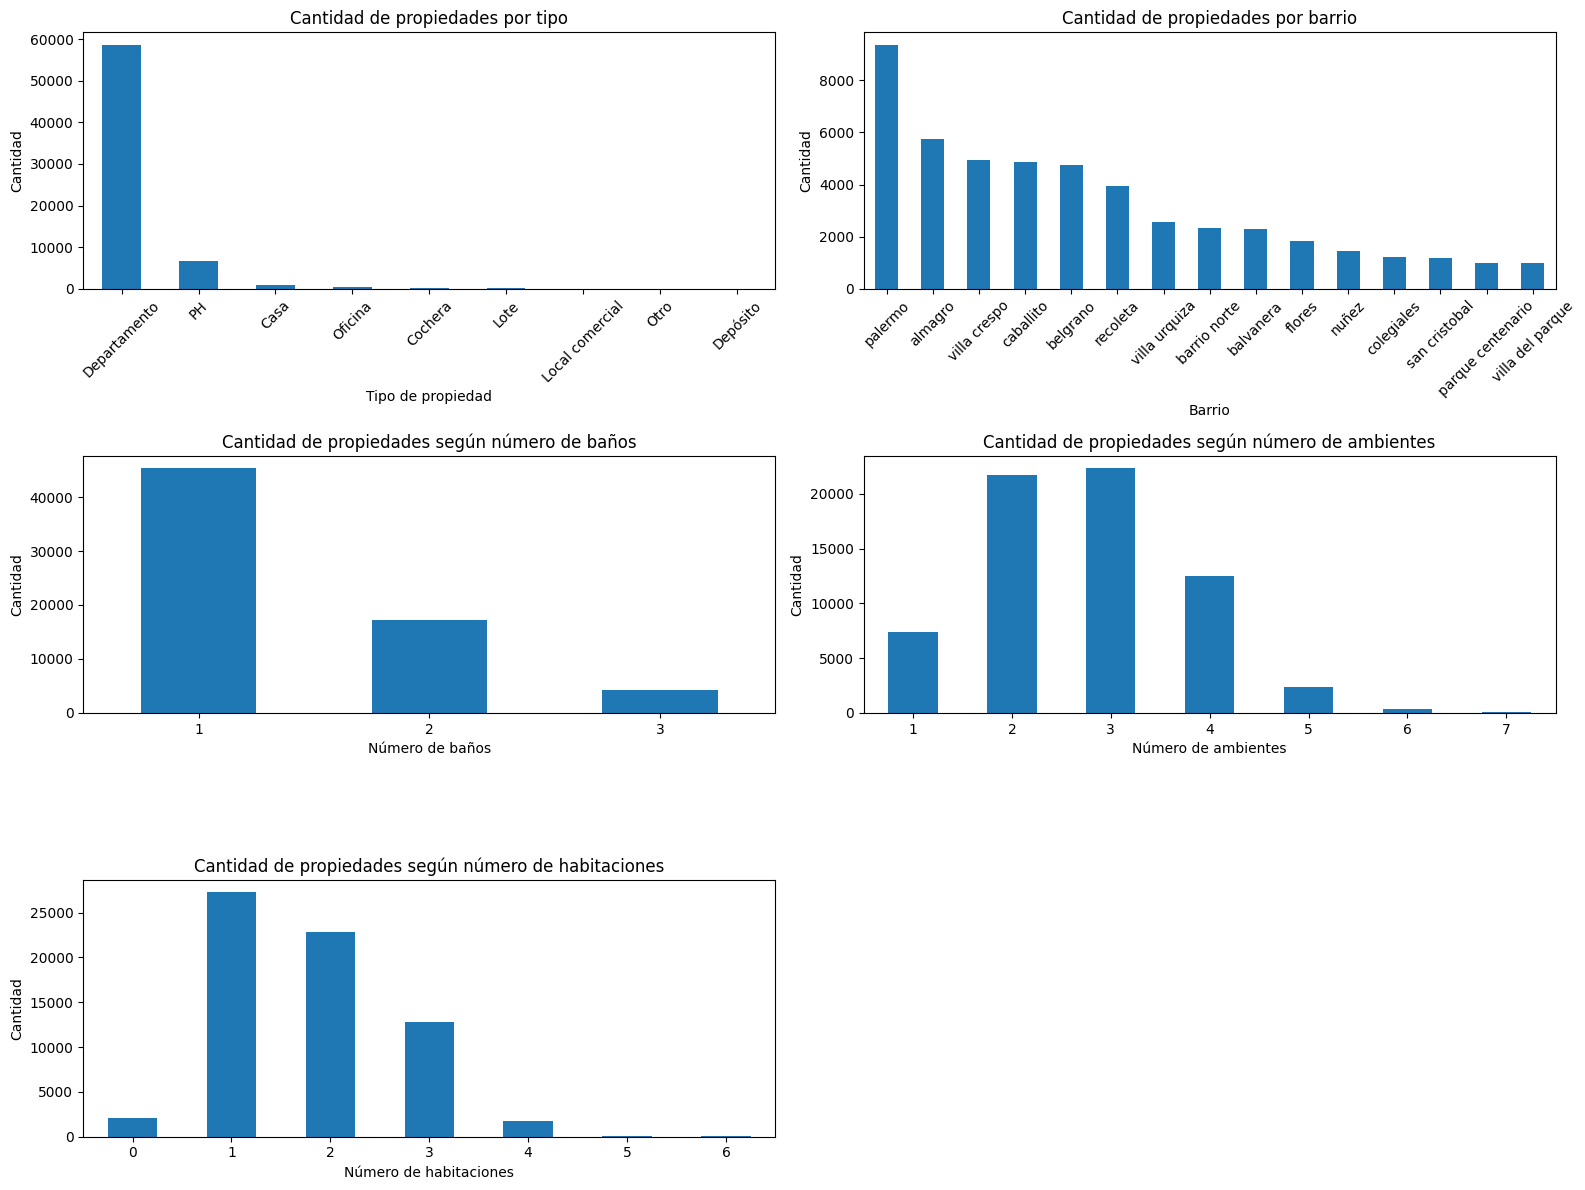

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes = axes.flatten()

X_train["property_type"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Cantidad de propiedades por tipo")
axes[0].set_xlabel("Tipo de propiedad")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=45)

X_train["barrio"].value_counts().head(15).plot(kind="bar", ax=axes[1])
axes[1].set_title("Cantidad de propiedades por barrio")
axes[1].set_xlabel("Barrio")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=45)

X_train["bathrooms"].value_counts().sort_index().head(15).plot(kind="bar",ax=axes[2])
axes[2].set_title("Cantidad de propiedades según número de baños")
axes[2].set_xlabel("Número de baños")
axes[2].set_ylabel("Cantidad")
axes[2].tick_params(axis="x", rotation=0)

X_train["rooms"].value_counts().sort_index().head(15).plot(kind="bar", ax=axes[3])
axes[3].set_title("Cantidad de propiedades según número de ambientes")
axes[3].set_xlabel("Número de ambientes")
axes[3].set_ylabel("Cantidad")
axes[3].tick_params(axis="x", rotation=0)

X_train["bedrooms"].value_counts().sort_index().head(15).plot(kind="bar", ax=axes[4])
axes[4].set_title("Cantidad de propiedades según número de habitaciones")
axes[4].set_xlabel("Número de habitaciones")
axes[4].set_ylabel("Cantidad")
axes[4].tick_params(axis="x", rotation=0)

axes[5].axis("off")

plt.tight_layout()
plt.show()

Se observa un claro predominio de departamentos dentro del conjunto de datos, mientras que el resto de los tipos de propiedad tienen una presencia mucho menor. En cuanto a la ubicación, Palermo es el barrio con mayor cantidad de publicaciones, seguido por Almagro, Villa Crespo, Caballito y Belgrano. Respecto a las características de las propiedades, predominan aquellas con 1 baño, 2 o 3 ambientes y entre 1 y 2 habitaciones, mientras que las propiedades con mayor cantidad de baños, ambientes o dormitorios aparecen con mucha menor frecuencia.

- 5.4) **Relaciones entre variables**
  - Graficar diagramas de dispersión entre variables relevantes y el precio (sug: `scatterplot()`, `sns.pairplot()`).
  - Calcular matriz de correlación y visualizar (sug: `imshow` o `sns.heatmap()`).

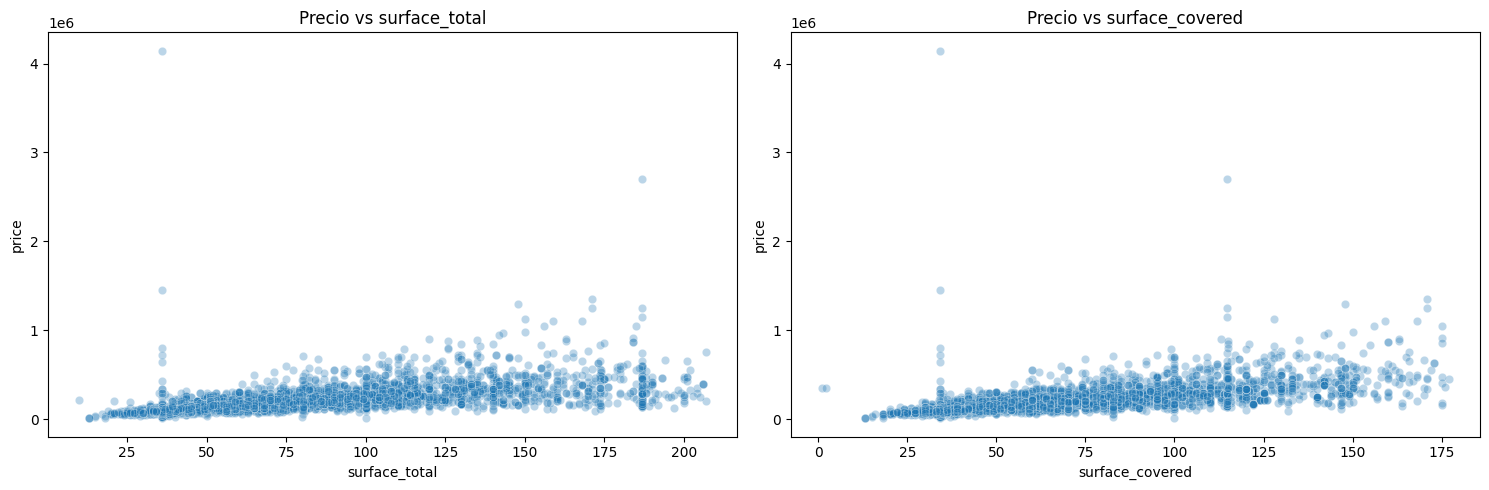

In [30]:
X_train["price"] = y_train.loc[X_train.index]
df_plot = X_train.sample(min(5000, len(X_train)), random_state=42)

variables = [
    "surface_total",
    "surface_covered"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in zip(axes.flatten(), variables):
    sns.scatterplot(
        data=df_plot,
        x=col,
        y="price",
        alpha=0.3,
        ax=ax)
    
    ax.set_title(f"Precio vs {col}")

plt.tight_layout()
plt.show()

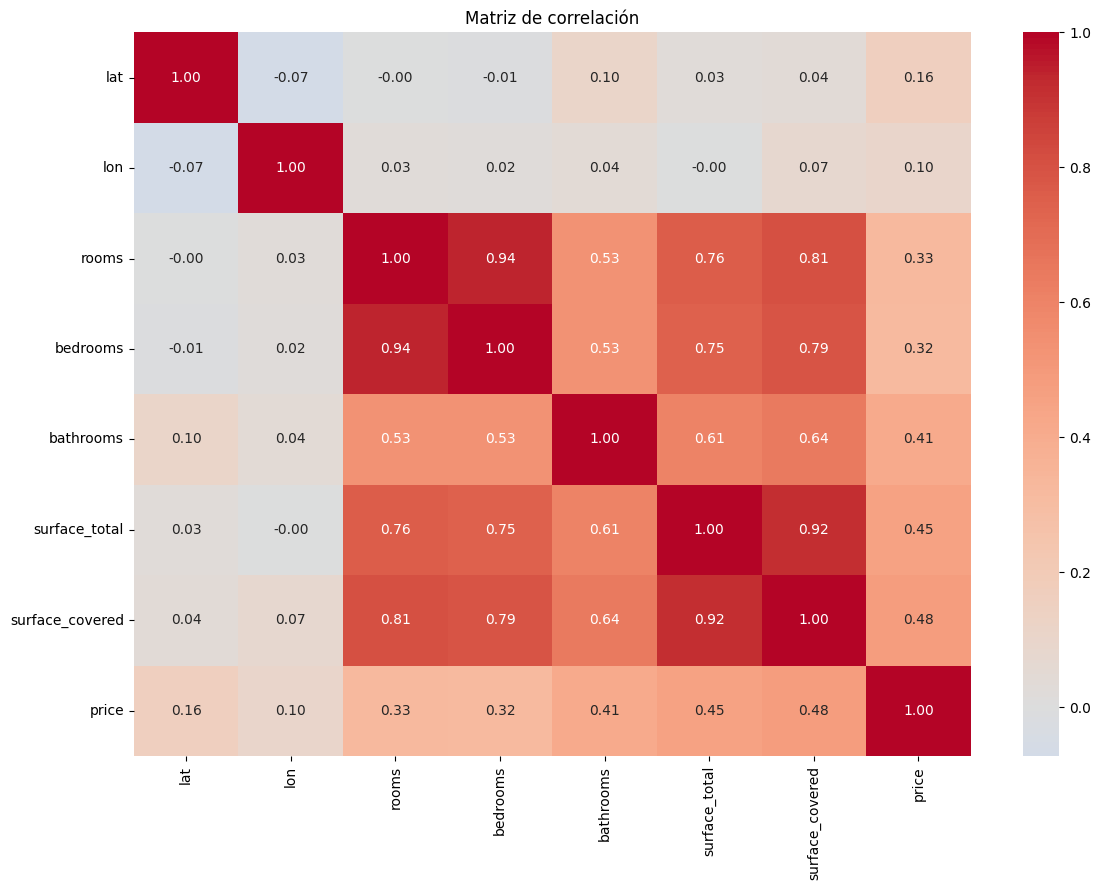

In [31]:
# Seleccionamos únicamente las variables numéricas
corr = X_train.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = X_train.select_dtypes(include=np.number).copy()
X_vif = X_vif.dropna()
X_vif_const = add_constant(X_vif)
vif = pd.DataFrame()
vif["variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i + 1)
    for i in range(len(X_vif.columns))]
vif.sort_values("VIF", ascending=False)

,variable,VIF
2,rooms,9.280052
3,bedrooms,8.777072
6,surface_covered,8.469095
5,surface_total,6.445943
4,bathrooms,1.776460
7,price,1.395321
1,lon,1.054157
0,lat,1.048006


# 6. Preparar los datos para modelos de ML

- 6.1) **Selección de variables**
  - Opcional: Aplicar ingeniería de features (ej: transformaciones o nuevas variables a partir de las presentes).
  - Seleccionar un conjunto prometedor de variables predictoras para el entrenamiento.

In [34]:
X_train.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'rooms',
       'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'barrio', 'price'],
      dtype='object')

In [35]:
# Superficie y ambientes
X_train["cover_ratio"] = X_train["surface_covered"] / X_train["surface_total"]
X_train["uncovered_surface"] = X_train["surface_total"] - X_train["surface_covered"]
X_train["surface_per_room"] = X_train["surface_total"] / (X_train["rooms"] + 1)

# Palabras (amenities) en la descripción o título (no implica que realmente tenga el amenitie, solo que lo menciona en la descripción o título)
keywords = [
    "pileta",
    "cochera",
    "balcon",
    "terraza",
    "patio",
    "jardin",
    "parrilla",
    "sum",
    "seguridad",
    "luminoso",
    "reciclado",
    "estrenar",
    "amenities"]

text = (X_train["title"].fillna("") + " " + X_train["description"].fillna("")).str.lower()

for word in keywords:
    X_train[f"has_{word}"] = text.str.contains(word, regex=False).astype(int)

# Fechas
X_train["start_year"] = X_train["start_date"].dt.year
X_train["start_month"] = X_train["start_date"].dt.month
X_train["start_day"] = X_train["start_date"].dt.day

In [36]:
# Superficie y ambientes
X_test["cover_ratio"] = X_test["surface_covered"] / X_test["surface_total"]
X_test["uncovered_surface"] = X_test["surface_total"] - X_test["surface_covered"]
X_test["surface_per_room"] = X_test["surface_total"] / (X_test["rooms"] + 1)

# Palabras (amenities) en la descripción o título (no implica que realmente tenga el amenitie, solo que lo menciona en la descripción o título)
keywords = [
    "pileta",
    "cochera",
    "balcon",
    "terraza",
    "patio",
    "jardin",
    "parrilla",
    "sum",
    "seguridad",
    "luminoso",
    "reciclado",
    "estrenar",
    "amenities"]

text = (X_test["title"].fillna("") + " " + X_test["description"].fillna("")).str.lower()

for word in keywords:
    X_test[f"has_{word}"] = text.str.contains(word, regex=False).astype(int)

# Fechas
X_test["start_year"] = X_test["start_date"].dt.year
X_test["start_month"] = X_test["start_date"].dt.month
X_test["start_day"] = X_test["start_date"].dt.day

In [37]:
X_train = X_train.drop(columns=["description","title","start_date","end_date"])

Por lógica dropeamos end_date al ser una variable que se obtiene luego de la venta por lo que podría ser una fuente de posible leakage

- 6.2) **Codificación de variables categóricas**

---


*Los modelos de aprendizaje automático trabajan principalmente con valores numéricos, por lo que las variables categóricas deben transformarse antes de poder ser utilizadas en el entrenamiento del modelo. Este proceso se conoce como codificación de variables categóricas. Existen diferentes estrategias para hacerlo. Por ejemplo, OrdinalEncoder se utiliza cuando las categorías tienen un orden natural (por ejemplo: bajo, medio, alto), mientras que OneHotEncoder se utiliza cuando las categorías no tienen un orden específico (por ejemplo: tipos de barrio o tipo de propiedad). En esta etapa será necesario identificar las variables categóricas del dataset y decidir qué método de codificación es más adecuado para cada una de ellas antes de continuar con el proceso de modelado.*

---

  - Usar `OneHotEncoder` o `OrdinalEncoder`  para variables categóricas (decidir cual).



In [38]:
X_train.columns

Index(['created_on', 'lat', 'lon', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'property_type', 'barrio', 'price',
       'cover_ratio', 'uncovered_surface', 'surface_per_room', 'has_pileta',
       'has_cochera', 'has_balcon', 'has_terraza', 'has_patio', 'has_jardin',
       'has_parrilla', 'has_sum', 'has_seguridad', 'has_luminoso',
       'has_reciclado', 'has_estrenar', 'has_amenities', 'start_year',
       'start_month', 'start_day'],
      dtype='object')

In [39]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["property_type", "barrio"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(X_train[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)

X_train = X_train.drop(columns=cat_cols)
X_train = pd.concat([X_train, encoded_df], axis=1)

X_train.head()

,created_on,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,cover_ratio,...,barrio_villa general mitre,barrio_villa lugano,barrio_villa luro,barrio_villa ortuzar,barrio_villa pueyrredón,barrio_villa real,barrio_villa riachuelo,barrio_villa santa rita,barrio_villa soldati,barrio_villa urquiza
52709,2019-07-29,-34.625519,-58.415173,3,2,1,55.0,55.0,125000.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83370,2020-01-25,-34.597355,-58.447126,2,1,1,37.0,37.0,65000.0,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53474,2019-05-03,-34.595118,-58.509362,3,2,1,57.0,54.0,138000.0,0.947368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40310,2019-12-19,-34.568029,-58.451498,4,3,3,145.0,133.0,429000.0,0.917241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121741,2019-10-28,-34.603699,-58.381163,3,2,2,105.0,59.0,148000.0,0.561905,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 6.3) **Escalado de variables numéricas**
---

*Luego se aplica el escalado de las variables numéricas, por ejemplo mediante ```StandardScaler```. Este paso es importante porque muchas variables pueden estar en escalas muy diferentes (por ejemplo, superficie en metros cuadrados frente a número de baños). El escalado permite que las variables tengan una distribución comparable, lo que facilita el aprendizaje del modelo y mejora la estabilidad de algunos algoritmos.*

*Es fundamental realizar el escalado después de separar los datos. El escalador debe ajustarse únicamente utilizando el conjunto de entrenamiento (fit), y luego aplicarse tanto al conjunto de entrenamiento como al de prueba (transform). De esta manera se evita que el modelo tenga acceso indirecto a información del conjunto de prueba durante el entrenamiento, lo que podría generar una evaluación demasiado optimista del rendimiento del modelo (problema conocido como data leakage).*

---
  - Normalizar las variables numéricas (sug: `StandardScaler`).

In [40]:
num_cols = [
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered",
    "cover_ratio",
    "uncovered_surface",
    "start_year",
    "start_month",
    "start_day"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [41]:
X_train.head()

,created_on,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,cover_ratio,...,barrio_villa general mitre,barrio_villa lugano,barrio_villa luro,barrio_villa ortuzar,barrio_villa pueyrredón,barrio_villa real,barrio_villa riachuelo,barrio_villa santa rita,barrio_villa soldati,barrio_villa urquiza
52709,2019-07-29,-34.625519,-58.415173,0.254144,0.243634,-0.638979,-0.531130,-0.369746,125000.0,0.645716,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83370,2020-01-25,-34.597355,-58.447126,-0.701254,-0.873119,-0.638979,-0.986888,-0.936082,65000.0,0.645716,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53474,2019-05-03,-34.595118,-58.509362,0.254144,0.243634,-0.638979,-0.480490,-0.401209,138000.0,0.288076,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40310,2019-12-19,-34.568029,-58.451498,1.209542,1.360387,2.665803,1.747663,2.084379,429000.0,0.083359,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
121741,2019-10-28,-34.603699,-58.381163,0.254144,0.243634,1.013412,0.734866,-0.243893,148000.0,-2.331206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 7. Entrenamiento

- 7.1) **Probar 3 modelos**
  - Regresión lineal (`LinearRegression`).
  - Regresión lineal regularizada (`Ridge` o `Lasso`).
  - Regresión polinomial regularizada (combinando `PolynomialFeatures` con `Ridge` o `Lasso`).
  - Ir siempre de lo más simple a lo más complejo.


In [ ]:
# su código



- 7.2) **Evaluar y comparar**
  - Evaluar los modelos **solo** en el conjunto de validación usando `cross_val_score`.

In [ ]:
# su código

# 8. Ajuste fino



- 8.1) **Buscar los mejores hiperparámetros**
  - Para los modelos con hiperparámetros (como `alpha`  y/o `degree`), hacer un ajuste fino por validación cruzada (sug: `GridSearch` o `RandomizedSearch`).
  - Elegir **un modelo final** basandose en las métricas de validación cruzada. Hacer un gráfico de barras comparando el RMSE de validación de los modelos comparados.
  - Especificar cuál es el modelo elegido, sus hiperparámetros y variables de entrada (*features*).

In [ ]:
# su código

# 9. Testeo

- 9.1) **Finalmente, evaluar el modelo final en el conjunto de testeo para medir el error de generalización**
  - Calcular el RMSE del modelo final (en test) y visualizar predicciones vs valores reales en un scatterplot.
  - ¿Cuáles fueron las features más importantes?, ¿Pueden hacer alguna interpretación?
  - ¿Pueden decir algo sobre los errores que comete el modelo?

In [ ]:
# su código

# 10. Resumen del proceso de Machine Learning (texto a completar)

Completen este texto que explica como se contruye estos modelos de ML.

Por favor, hagan una lista de las palabras:
eg: 1= XXXX; 2=XXXX...



El objetivo de este trabajo práctico es construir un modelo de __________ (1) para predecir el __________ (2) de una vivienda a partir de diferentes características del dataset.

Antes de entrenar un modelo de Machine Learning, es necesario realizar un __________ (3) del conjunto de datos para comprender su estructura. Para ello se utilizan funciones como __________ (4), __________ (5) y __________ (6), que permiten observar las primeras filas del dataset, los tipos de datos y las estadísticas descriptivas de cada variable.

Luego es importante verificar la presencia de __________ (7) en el dataset. Estos valores pueden ser eliminados o reemplazados mediante diferentes estrategias de __________ (8).

También se analizan las __________ (9) de las variables mediante gráficos como __________ (10) o __________ (11), lo que permite detectar posibles __________ (12) que podrían afectar el modelo.

Una vez comprendidas las variables, es útil analizar las __________ (13) entre ellas. Para ello se pueden utilizar gráficos de __________ (14) y matrices de __________ (15) que ayudan a identificar qué variables están más relacionadas con la variable objetivo.

En muchos datasets existen variables __________ (16) que no pueden ser utilizadas directamente por los modelos de Machine Learning. Por esta razón es necesario transformarlas mediante técnicas de __________ (17) como __________ (18) o __________ (19).

Una vez preparados los datos, el siguiente paso es separar el dataset en dos conjuntos: __________ (20) y __________ (21). Esta separación permite entrenar el modelo en un conjunto de datos y evaluar su rendimiento en datos que no ha visto previamente.

Después de la separación, se realiza el __________ (22) de las variables numéricas utilizando herramientas como __________ (23). Este paso es importante porque las variables pueden tener __________ (24) muy diferentes, lo que podría afectar el aprendizaje del modelo.

Es importante aplicar el escalado después de la separación de los datos para evitar el problema conocido como __________ (25).

Finalmente, se entrena un modelo de __________ (26) utilizando los datos de entrenamiento. Este modelo aprende una relación entre las variables de entrada y la variable objetivo, generalmente representada por una ecuación de la forma:
y=β0+β1x1+β2x2+...

donde __________ (27) representa la variable a predecir, __________ (28) son las variables explicativas y los coeficientes __________ (29) representan el impacto de cada variable en la predicción.

Una vez entrenado el modelo, su rendimiento se evalúa utilizando el conjunto de __________ (30) mediante métricas como __________ (31), __________ (32) o __________ (33).

Este proceso permite construir un modelo capaz de __________ (34) el precio de nuevas viviendas a partir de sus características.